In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
import drjit as dr
import drjit.nn as dnn
from drjit.opt import Adam, GradScaler
from pathlib import Path
from drjit.cuda.ad import Float32, Float16, TensorXf16, UInt32, Bool
from drjit.llvm.ad import Float16 as cpuFloat16, TensorXf16 as cpuTensorXf16, Float32 as cpuFloat32
import torch
from tqdm import tqdm
data = np.load('3D_boxsplines.npy')
data /= data.max()
weights_path = Path('3D_spline_weights.npz')
W = np.load(weights_path)['weights']

In [2]:
rng_net = dr.rng(seed=0)
net_ref = dnn.Sequential(
    dnn.Linear(4, 16, bias=True),
    dnn.ReLU(),
    dnn.Linear(16, 16, bias=True),
    dnn.ReLU(),
    dnn.Linear(16, 16, bias=True),
    dnn.ReLU(),
    dnn.Linear(16, 16, bias=True),
    dnn.ReLU(),
    dnn.Linear(16, 1, bias=True)
)
net_ref = net_ref.alloc(dtype=cpuTensorXf16, size=4, rng=rng_net)
weights_ref, net_ref = dnn.pack(net_ref, layout='inference')
weights_ref[:] = cpuFloat16(W)

In [ ]:
rng_net = dr.rng(seed=0)
net = dnn.Sequential(
    dnn.Linear(4, 16, bias=True),
    dnn.ReLU(),
    dnn.Linear(16, 16, bias=True),
    dnn.ReLU(),
    dnn.Linear(16, 16, bias=True),
    dnn.ReLU(),
    dnn.Linear(16, 16, bias=True),
    dnn.ReLU(),
    dnn.Linear(16, 1, bias=True)
)
net = net.alloc(dtype=TensorXf16, size=4, rng=rng_net)
weights, net = dnn.pack(net, layout='training')

opt = Adam(lr=1e-5, params={'weights': Float16(weights)})
scaler = GradScaler()
N = 1000
for i in tqdm(range(400000)):
    # Update network state from optimizer
    weights[:] = Float16(opt['weights'])
    theta = np.random.uniform(0, np.pi, size=N)
    costheta = np.cos(theta)
    sintheta = np.sin(theta)
    x = np.random.uniform(-2, 2, size=N)
    y = np.random.uniform(-2, 2, size=N)

    features = dnn.CoopVec(
        Float16(costheta),
        Float16(sintheta),
        Float16(x),
        Float16(y)
    )
    prediction, = net(features)

    cpu_features = dnn.CoopVec(
        cpuFloat16(costheta),
        cpuFloat16(sintheta),
        cpuFloat16(x),
        cpuFloat16(y)
    )
    ref_target, = net_ref(cpu_features)
    ref_cpu = ref_target.numpy().astype(np.float16)
    ref_target_ = Float16(ref_cpu)

    loss = dr.sum(Float16(prediction) - ref_target_) ** 2
    dr.backward(scaler.scale(loss))
    scaler.step(opt)

    if i % 5000 == 0:
        print(f"Iteration {i}: Loss = {loss.item()}")
    


  0%|          | 1/400000 [00:00<70:06:13,  1.58it/s]

Iteration 0: Loss = 4160.0


  1%|▏         | 5044/400000 [00:11<13:48, 476.59it/s]

Iteration 5000: Loss = 8.2890625


  3%|▎         | 10074/400000 [00:21<13:05, 496.22it/s]

Iteration 10000: Loss = 0.1280517578125


  4%|▍         | 15085/400000 [00:32<12:58, 494.53it/s]

Iteration 15000: Loss = 14.5234375


  4%|▍         | 15685/400000 [00:50<13:07, 487.90it/s]

## TESTING

Building training grid...


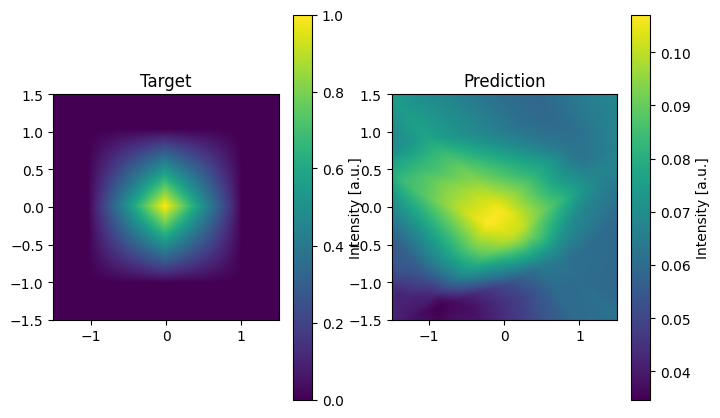

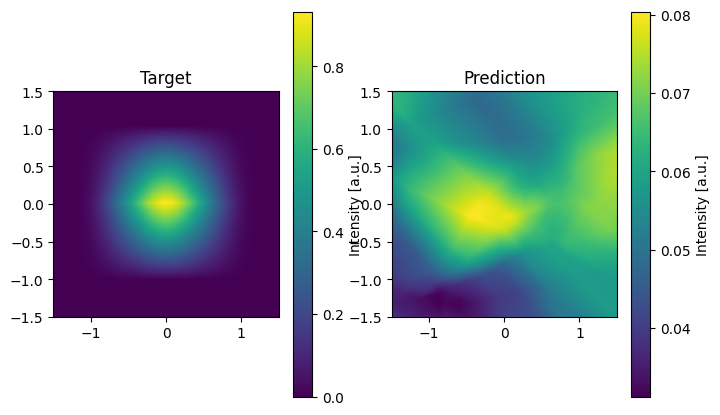

In [ ]:
def coop_to_float(cv):
    component, = cv
    return Float(component)

N = 100
L = 1.5
x_values = np.linspace(-L, L, N, dtype=np.float32)
y_values = np.linspace(-L, L, N, dtype=np.float32)
theta_values = np.linspace(0.0, np.pi, N, endpoint=False, dtype=np.float32)

print("Building training grid...")
XX, YY, TT = np.meshgrid(x_values, y_values, theta_values, indexing='ij')
x_flat = XX.ravel()
y_flat = YY.ravel()
theta_flat = TT.ravel()

sin_flat = np.sin(theta_flat).astype(np.float32)
cos_flat = np.cos(theta_flat).astype(np.float32)

def nearest_index(vals, grid):
    step = grid[1] - grid[0]
    return np.clip(np.round((vals - grid[0]) / step).astype(np.int64), 0, len(grid) - 1)

idx_theta = nearest_index(theta_flat, theta_values)
idx_y = nearest_index(y_flat, y_values)
idx_x = nearest_index(x_flat, x_values)
targets_np = data[idx_theta, idx_y, idx_x].astype(np.float32).reshape(-1, 1)

features_np = np.stack([
    x_flat.astype(np.float32),
    y_flat.astype(np.float32),
    sin_flat,
    cos_flat
], axis=1)

num_samples = features_np.shape[0]
train = False  # Set to False to reuse the PyTorch checkpoint instead of training.
torch_weights_path = Path('3D_boxsplines_model.pth')

Float = Float16
FloatAcc = Float32
UInt = dr.uint32_array_t(FloatAcc)

feature_components = [Float(features_np[:, i]) for i in range(features_np.shape[1])]
target_components = Float(targets_np[:, 0])
train_inputs = dnn.CoopVec(*feature_components)
train_targets = target_components
training_volume = targets_np.reshape(N, N, N)

train_prediction = coop_to_float(net(train_inputs))
train_prediction_np = np.array(dr.detach(train_prediction)).reshape(N, N, N)

plt.figure(figsize=(8, 5))
plt.subplot(1, 2, 1)
plt.title('Target')
plt.imshow(training_volume[:, :, 0], extent=(-L, L, -L, L))
plt.colorbar(label='Intensity [a.u.]')
plt.subplot(1, 2, 2)
plt.title('Prediction')
plt.imshow(train_prediction_np[:, :, 0], extent=(-L, L, -L, L))
plt.colorbar(label='Intensity [a.u.]')
plt.show()

plt.figure(figsize=(8, 5))
plt.subplot(1, 2, 1)
plt.title('Target')
plt.imshow(training_volume[:, :, 12], extent=(-L, L, -L, L))
plt.colorbar(label='Intensity [a.u.]')
plt.subplot(1, 2, 2)
plt.title('Prediction')
plt.imshow(train_prediction_np[:, :, 12], extent=(-L, L, -L, L))
plt.colorbar(label='Intensity [a.u.]')
plt.show()
